### Baseline Model (Logistic Regression)

**Three preprocessing steps before modelling:**
1. Separate features (X) from the target (y)
2. Scale `age_of_respondent` — the only column not already on a 0–1 scale
3. Handle class imbalance — only 14% of respondents have a bank account

---

### Step 0 — Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

---
### Step 1 — Load the Data

In [2]:
df = pd.read_csv('data/features_encoded_train.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head(3)

Shape: 23,524 rows × 18 columns
Missing values: 0


,age_of_respondent,bin_location_type,bin_cellphone_access,bin_gender,ord_education_level,ohe_country_Rwanda,ohe_country_Tanzania,ohe_country_Uganda,ohe_job_Farming and Fishing,ohe_job_Formally employed Government,ohe_job_Formally employed Private,ohe_job_Government Dependent,ohe_job_Informally employed,ohe_job_No Income,ohe_job_Other Income,ohe_job_Remittance Dependent,ohe_job_Self employed,target_bank_account
0,24,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,1,1
1,70,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,26,1,1,1,3,0,0,0,0,0,0,0,0,0,0,0,1,1


---
### Step 2 — Check Class Imbalance

Before splitting, we check how balanced the target is. This matters because:
- If 86% of rows are class 0, a model that always predicts 0 gets 86% accuracy — but is useless
- We need metrics like **ROC-AUC** that are not fooled by class imbalance

In [3]:
target_col = 'target_bank_account'

counts = df[target_col].value_counts()
pcts = df[target_col].value_counts(normalize=True) * 100

print('Target distribution:')
print(f'  No bank account (0): {counts[0]:,}  ({pcts[0]:.1f}%)')
print(f'  Has bank account (1): {counts[1]:,}  ({pcts[1]:.1f}%)')
print(f'  Class imbalance ratio: {counts[0]/counts[1]:.1f}:1')

Target distribution:
  No bank account (0): 20,212  (85.9%)
  Has bank account (1): 3,312  (14.1%)
  Class imbalance ratio: 6.1:1


We will use class_weight="balanced" in the model to compensate.

---
### Step 3 — Separate X and Y, then Split

- **X** = all 17 feature columns (everything except the target)
- **y** = `target_bank_account` (what we want to predict)
- We split: 80% for training, 20% for validation
- `stratify=y` ensures both splits have the same 86/14 class ratio

In [4]:
X = df.drop(columns=[target_col])
y = df[target_col]

print(f'Features (X): {X.shape[1]} columns')
print(f'Target  (y): {y.name}')
print(f'\nFeature columns:')
for col in X.columns:
    print(f'  • {col}')

Features (X): 17 columns
Target  (y): target_bank_account

Feature columns:
  • age_of_respondent
  • bin_location_type
  • bin_cellphone_access
  • bin_gender
  • ord_education_level
  • ohe_country_Rwanda
  • ohe_country_Tanzania
  • ohe_country_Uganda
  • ohe_job_Farming and Fishing
  • ohe_job_Formally employed Government
  • ohe_job_Formally employed Private
  • ohe_job_Government Dependent
  • ohe_job_Informally employed
  • ohe_job_No Income
  • ohe_job_Other Income
  • ohe_job_Remittance Dependent
  • ohe_job_Self employed


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # preserve the class ratio in both splits
)

print(f'Training set  : {X_train.shape[0]:,} rows')
print(f'Validation set: {X_val.shape[0]:,} rows')
print(f'\nClass balance in train: {y_train.mean()*100:.1f}% positive')
print(f'Class balance in val  : {y_val.mean()*100:.1f}% positive')

Training set  : 18,819 rows
Validation set: 4,705 rows

Class balance in train: 14.1% positive
Class balance in val  : 14.1% positive


---
### Step 4 — Scale Age

Logistic regression works best when all features are on a similar scale. Age (16–100) is much larger than all other columns (0–4 at most). We use `StandardScaler` which transforms a column to have mean=0 and std=1.

> **Important rule**: fit the scaler on training data only, then apply it to both train and validation. If we fitted on all data, we'd leak information from the validation set.

In [6]:
# Only age needs scaling — all other columns are already 0/1 or 0–4
cols_to_scale = ['age_of_respondent']

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train[cols_to_scale])

# Apply to both train and validation
X_train = X_train.copy()
X_val = X_val.copy()

X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_val[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])

print(f'age_of_respondent — after scaling:')
print(f'  Train: mean={X_train["age_of_respondent"].mean():.4f}, std={X_train["age_of_respondent"].std():.4f}')
print(f'  Val  : mean={X_val["age_of_respondent"].mean():.4f}, std={X_val["age_of_respondent"].std():.4f}')

age_of_respondent — after scaling:
  Train: mean=0.0000, std=1.0000
  Val  : mean=0.0061, std=1.0032


---
### Step 5 — Train the Logistic Regression

Key settings:
- `class_weight='balanced'` — automatically upweights the minority class (bank account = yes)
- `max_iter=1000` — more iterations to ensure convergence
- All 17 features are passed as X — the model learns a coefficient for every single column

In [7]:
model = LogisticRegression(
    class_weight='balanced',  # handles the 86/14 imbalance
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print('Model trained')
print(f'   Features used: {X_train.shape[1]}')
print(f'   Training rows: {X_train.shape[0]:,}')

Model trained
   Features used: 17
   Training rows: 18,819


---
### Step 6 — Evaluate on Validation Set

We evaluate using:
- **ROC-AUC** — the primary metric; measures how well the model separates the two classes (1.0 = perfect, 0.5 = random)
- **Classification report** — precision, recall, F1 per class
- **Confusion matrix** — shows how many true/false positives and negatives

In [8]:
# Predictions
y_pred = model.predict(X_val)              # hard labels (0 or 1)
y_proba = model.predict_proba(X_val)[:, 1] # probability of class 1

# ROC-AUC
auc = roc_auc_score(y_val, y_proba)
print(f'ROC-AUC score: {auc:.4f}')
print()

# Classification report
print('Classification report (validation set):')
print(classification_report(y_val, y_pred, target_names=['No bank account', 'Has bank account']))

ROC-AUC score: 0.8574

Classification report (validation set):
                  precision    recall  f1-score   support

 No bank account       0.95      0.78      0.86      4043
Has bank account       0.36      0.76      0.49       662

        accuracy                           0.78      4705
       macro avg       0.66      0.77      0.68      4705
    weighted avg       0.87      0.78      0.81      4705



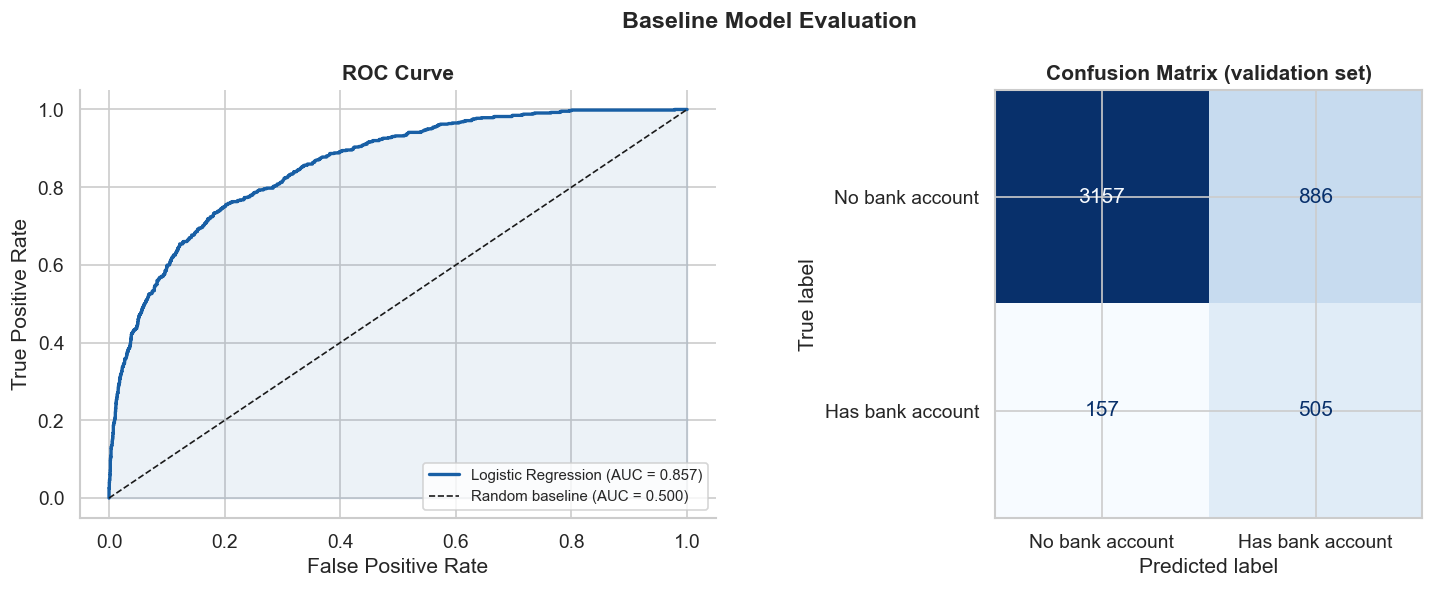

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_val, y_proba)
axes[0].plot(fpr, tpr, color='#185FA5', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#185FA5')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No bank account', 'Has bank account'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (validation set)', fontweight='bold')

plt.suptitle('Baseline Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Step 7 — Feature Coefficients

We chose Logistic regression beacause it is fully interpretable. This is where the one-hot job columns pay off, we can explain step-by-step to our stakeholders.

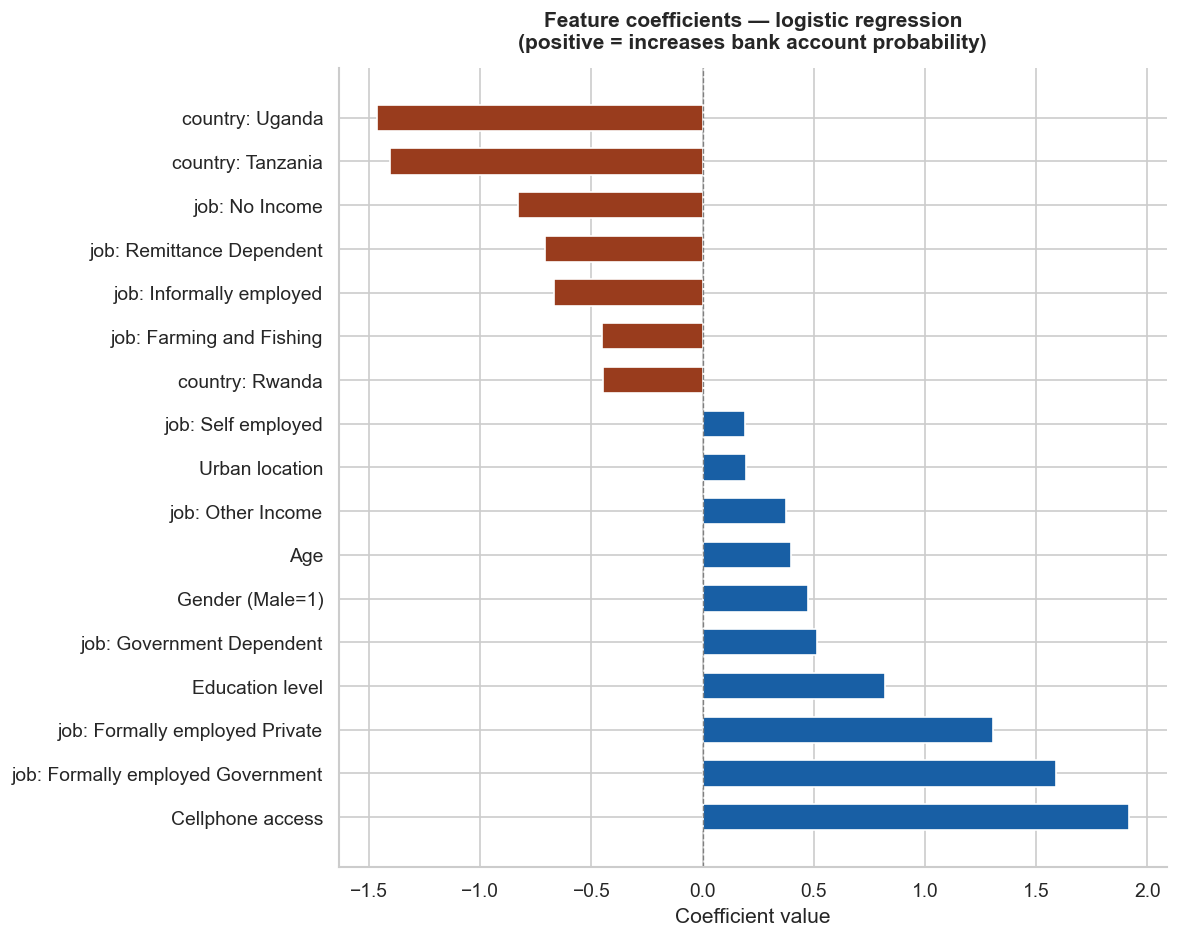


Top 5 positive (most associated with having a bank account):
                            label  coefficient
                 Cellphone access     1.917337
job: Formally employed Government     1.590147
   job: Formally employed Private     1.306677
                  Education level     0.818508
        job: Government Dependent     0.514296

Top 5 negative (most associated with NOT having a bank account):
                    label  coefficient
 job: Informally employed    -0.669762
job: Remittance Dependent    -0.707460
           job: No Income    -0.830003
        country: Tanzania    -1.403808
          country: Uganda    -1.465453


In [10]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

# Clean up labels for readability
coef_df['label'] = (coef_df['feature']
    .str.replace('ohe_job_', 'job: ', regex=False)
    .str.replace('ohe_country_', 'country: ', regex=False)
    .str.replace('bin_location_type', 'Urban location', regex=False)
    .str.replace('bin_cellphone_access', 'Cellphone access', regex=False)
    .str.replace('bin_gender', 'Gender (Male=1)', regex=False)
    .str.replace('ord_education_level', 'Education level', regex=False)
    .str.replace('age_of_respondent', 'Age', regex=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#185FA5' if v >= 0 else '#993C1D' for v in coef_df['coefficient']]
bars = ax.barh(coef_df['label'], coef_df['coefficient'],
               color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Feature coefficients — logistic regression\n(positive = increases bank account probability)',
             fontweight='bold', pad=12)
ax.set_xlabel('Coefficient value')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nTop 5 positive (most associated with having a bank account):')
print(coef_df.head(5)[['label','coefficient']].to_string(index=False))
print('\nTop 5 negative (most associated with NOT having a bank account):')
print(coef_df.tail(5)[['label','coefficient']].to_string(index=False))

---
### Step 8 — Summary


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('=' * 50)
print('  BASELINE MODEL SUMMARY')
print('=' * 50)
print(f'  Model          : Logistic Regression')
print(f'  Features used  : {X_train.shape[1]}')
print(f'  Train rows     : {X_train.shape[0]:,}')
print(f'  Val rows       : {X_val.shape[0]:,}')
print(f'  Class weight   : balanced')
print()
print(f'  ROC-AUC        : {auc:.4f}')
print(f'  Accuracy       : {accuracy_score(y_val, y_pred):.4f}')
print(f'  Precision (1)  : {precision_score(y_val, y_pred):.4f}')
print(f'  Recall (1)     : {recall_score(y_val, y_pred):.4f}')
print(f'  F1 (1)         : {f1_score(y_val, y_pred):.4f}')
print('=' * 50)

  BASELINE MODEL SUMMARY
  Model          : Logistic Regression
  Features used  : 17
  Train rows     : 18,819
  Val rows       : 4,705
  Class weight   : balanced

  ROC-AUC        : 0.8574
  Accuracy       : 0.7783
  Precision (1)  : 0.3630
  Recall (1)     : 0.7628
  F1 (1)         : 0.4920


Next steps to try:
  → Random Forest or XGBoost (handles non-linearity)
  → Tune decision threshold (default 0.5 may not be optimal)
  → Cross-validation instead of single train/val split
  → SMOTE oversampling as an alternative to class_weight

---
### Step 9 — Iteration / Tweaking the Model

From the perspective of an individual assessing their own chances, the worst outcome is being told "you're unlikely to get a bank account" when you actually could. That's the 157 missed cases — real people who have accounts but the model incorrectly discouraged them. This is called a false negative.
So our goal is: catch more of the 157 missed cases, even if it means more false alarms.

In [21]:
# Predictions
y_proba = model.predict_proba(X_val)[:, 1] # probability of class 1
threshold = 0.4  # lower = catches more bank account cases
y_pred = (y_proba >= threshold).astype(int)

# ROC-AUC
auc = roc_auc_score(y_val, y_proba)
print(f'ROC-AUC score: {auc:.4f}')
print()

# Classification report
print('Classification report (validation set):')
print(classification_report(y_val, y_pred, target_names=['No bank account', 'Has bank account']))

ROC-AUC score: 0.8574

Classification report (validation set):
                  precision    recall  f1-score   support

 No bank account       0.96      0.67      0.79      4043
Has bank account       0.29      0.85      0.44       662

        accuracy                           0.69      4705
       macro avg       0.63      0.76      0.61      4705
    weighted avg       0.87      0.69      0.74      4705



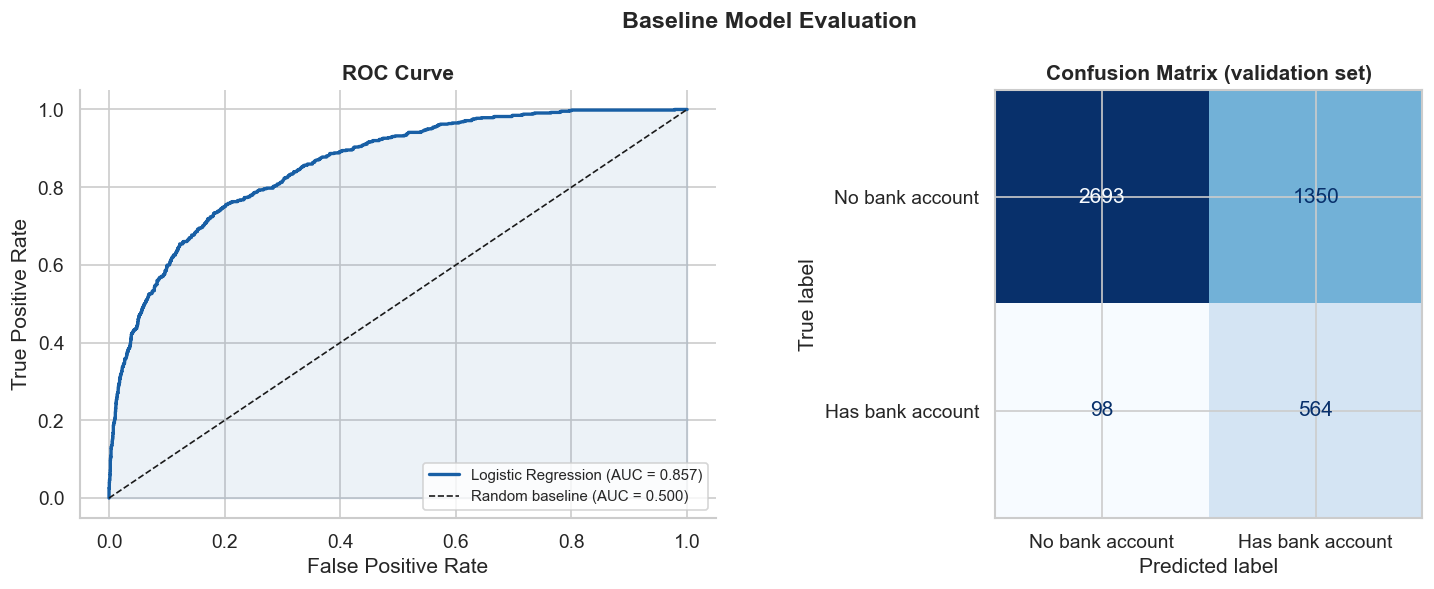

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_val, y_proba)
axes[0].plot(fpr, tpr, color='#185FA5', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#185FA5')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No bank account', 'Has bank account'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (validation set)', fontweight='bold')

plt.suptitle('Baseline Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

A decrease of the Threshold from 0.5 to 0.4 reduces 'false negative' cases by approx. 40%. while increase 'false positve' by approx. 35%. This is a tradeoff worth being taken into account. 